# **Cleaning The Suicidality Dataset**

In this notebook, we will explore the data quality of the dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import re

seed = 42

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
original = pd.read_csv("Suicidal Ideation Detection reddit Dataset.csv")
df = original.copy()

df

,Title,Post,Label
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal
...,...,...,...
15472,"Once I die, I can finally be at rest.","My past actions will no longer haunt me, hopef...",Suicidal
15473,I just want to stop.,I just want to stop living. I’ve lost everythi...,Suicidal
15474,I’m still alive,WHY THE FUCK AM I STILL ALIVE. WHY WONT I JUST...,Suicidal
15475,I'm lonely but I can't stand people,"It's a lot better online, but irl I can't stan...",Suicidal


For preference and ease of access, we also the column names to lowercase.

In [3]:
df.columns = df.columns.str.lower()

In [4]:
df.head()

,title,post,label
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal


## **Data Exploration and Cleaning**

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15477 entries, 0 to 15476
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   title   15477 non-null  str  
 1   post    14243 non-null  str  
 2   label   15477 non-null  str  
dtypes: str(3)
memory usage: 362.9 KB


Observations:
- There are some missing values for the post feature
- All features have the correct data type

In [6]:
df.describe()

,title,post,label
count,15477,14243,15477
unique,15182,14230,3
top,Help,.,Non-Suicidal
freq,16,6,8201


Observations:
- There are some duplicates for title and post. 
- Label has an extra class.

### Looking into the Suicidality Label

In [7]:
df["label"].unique()

<StringArray>
['Non-Suicidal', 'Label', 'Suicidal']
Length: 3, dtype: str

The "Label" label appears to be an encoding error.

In [8]:
encoding_error = df[df["label"] == "Label"]
encoding_error

,title,post,label
7331,Captions,Posts,Label


This proves it to be an error, we remove this instance.

In [9]:
df = df.drop(index=encoding_error.index).reset_index(drop=True) # reset index for ease of access

In [10]:
label_count = df["label"].value_counts()

label_count

label
Non-Suicidal    8201
Suicidal        7275
Name: count, dtype: int64

Text(0.5, 0, 'Class')

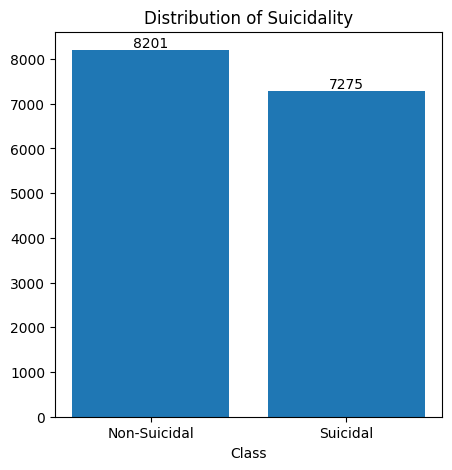

In [11]:
fig, ax = plt.subplots(figsize=[5,5])
bars = ax.bar(x=label_count.index, height=label_count)
ax.bar_label(bars)
ax.set_title("Distribution of Suicidality")
ax.set_xlabel("Class")

There is around 1000 instance difference between classes.

### Missing Data Check

Earlier, we noticed that the post feature has a lot of missing values. Let us look into this feature.

In [12]:
missing_post = df[df["post"].isna()]

missing_post

,title,post,label
1007,Just a very important reminder for everyone to...,NaN,Non-Suicidal
1009,Does this count as a cat?,NaN,Non-Suicidal
1016,I bought a pumpkin for £20 and made it into a ...,NaN,Non-Suicidal
1097,Girlfriends grandmother is a great artist and ...,NaN,Non-Suicidal
1146,"My daughter's thrift store Joker costume, I th...",NaN,Non-Suicidal
...,...,...,...
15397,How to get over fear of death?,NaN,Suicidal
15413,I don't deserve to be alive im dumb haha,NaN,Suicidal
15416,Is anyone up to talk?,NaN,Suicidal
15451,I don't want to wait until I grow up. Why suff...,NaN,Suicidal


In [13]:
missing_post.value_counts(subset="label")

label
Non-Suicidal    765
Suicidal        469
Name: count, dtype: int64

Among the instances with missing posts, more of them are non-suicidal posts. In order to retain as much information as possible, we will deal with the missing values accordingly.

In [14]:
# Track which instance has posts
df["has_post"] = (~df["post"].isna()).astype(int) # Modeling purpose, having no post might be informational in the classification.

In [15]:
# Fill missing post with empty string
df["post"] = df["post"].fillna("")

#### Sanity Check
We view the info to see if the missing values are properly filled.

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15476 entries, 0 to 15475
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   title     15476 non-null  str  
 1   post      15476 non-null  str  
 2   label     15476 non-null  str  
 3   has_post  15476 non-null  int64
dtypes: int64(1), str(3)
memory usage: 483.8 KB


Through this, we can see that each column has equal non-null values.

### Duplicated Data Check
Earlier we noticed duplicate values in the title and post features, we validate whether they are truly duplicates.

In [17]:
duplicated_values = df[df[["title", "post"]].duplicated()] # text is the combined title and post
duplicated_values

,title,post,label,has_post


With this, we see that there are no duplicated values as a whole.

To further validate, we get a duplicated title and view its duplicates.

In [18]:
duplicated_title_test = df[df["title"].duplicated()]["title"].iloc[0]
duplicated_title_test

'I quit my job today.'

In [19]:
df[df["title"] == duplicated_title_test]

,title,post,label,has_post
188,I quit my job today.,I work for an agency and they've sent me to so...,Non-Suicidal,1
495,I quit my job today.,I quit my job today. Only lasted 4 months. But...,Non-Suicidal,1


We see that even if the title is the same, these are two different posts.

We do the same for post

In [20]:
duplicated_post_test = df[df["post"].duplicated() & (df["post"] != "")]["post"].iloc[0]
duplicated_post_test

'.'

We look into these period posts.

In [21]:
df[df["post"] == duplicated_post_test]

,title,post,label,has_post
1929,I wish I didn't have to age.,.,Non-Suicidal,1
8971,"I am supposed to be treated and I was happy,so...",.,Suicidal,1
10409,Hanging myself tonight so I avoid my birthday ...,.,Suicidal,1
12441,Just mixed Alprazolam with the Alchohol,.,Suicidal,1
14324,I noticed that I was on a downward spiral back...,.,Suicidal,1
15288,Why do good people die early,.,Suicidal,1


There are some posters who put their message on the title and leave the post blank. We can consider these as no post.

In [22]:
period_posts = df[df["post"] == "."]
period_posts

,title,post,label,has_post
1929,I wish I didn't have to age.,.,Non-Suicidal,1
8971,"I am supposed to be treated and I was happy,so...",.,Suicidal,1
10409,Hanging myself tonight so I avoid my birthday ...,.,Suicidal,1
12441,Just mixed Alprazolam with the Alchohol,.,Suicidal,1
14324,I noticed that I was on a downward spiral back...,.,Suicidal,1
15288,Why do good people die early,.,Suicidal,1


In [23]:
df.loc[period_posts.index, "has_post"] = 0
df.loc[period_posts.index, "post"] = ""

#### Sanity Check

We check if the period posts were properly cleaned.

In [24]:
df.loc[period_posts.index,:].head()

,title,post,label,has_post
1929,I wish I didn't have to age.,,Non-Suicidal,0
8971,"I am supposed to be treated and I was happy,so...",,Suicidal,0
10409,Hanging myself tonight so I avoid my birthday ...,,Suicidal,0
12441,Just mixed Alprazolam with the Alchohol,,Suicidal,0
14324,I noticed that I was on a downward spiral back...,,Suicidal,0


In here, we can see that each supposed period posts has been cleared and label as no post.

### Incorrect Data Check

We also look into a small sample from the dataset and validate their contents. 
Note: Since the task requires as much context as possible for each post, we will not be doing a lot of semantic cleaning (removal of stop words). 

In [25]:
data_sample = df.sample(20, random_state=seed) # Sample of 20
data_sample

,title,post,label,has_post
1459,Having a platonic female friend is one of the ...,I'm a straight guy but I met this female frien...,Non-Suicidal,1
13959,I am thinking of ending my life sooner or later.,I am 15 and i don’t see myself in another 10 y...,Suicidal,1
930,Started Dieting a few months ago and just star...,Early 30's guy and hit my peak of 335 lbs (152...,Non-Suicidal,1
12816,I just can’t,I don’t know anymore. This is just a vent so i...,Suicidal,1
4304,I hit 1 year clean from my eating disorder !,I’m genuinely shocked and happy that I’ve went...,Non-Suicidal,1
14618,The desire to kill myself is like a itch I nee...,I honestly can't take life anymore.\nI'm not s...,Suicidal,1
2927,I drank tap water!,"I have contamination OCD, along with comorbidi...",Non-Suicidal,1
12542,"Going to kill myself tomorrow or so, I failed ...",My comment on r /furby got 3 downvotes. These ...,Suicidal,1
5456,"I am almost out of dishwasher pods, but the ne...",,Non-Suicidal,0
99,"In the third week, of the third month, of the ...",It’s not the third day of the week but it is T...,Non-Suicidal,1


In [26]:
for i in list(data_sample.index):
    title = data_sample.loc[i, "title"]
    post = data_sample.loc[i, "post"]
    label = data_sample.loc[i, "label"]
    
    print(f"Post {i+1} ({label}): {title}\n{post}\n\n")

Post 1460 (Non-Suicidal): Having a platonic female friend is one of the best things that happened to me
I'm a straight guy but I met this female friend a while ago and I gotta say it's one of the best things ever. Unlike most of my male friends, we talk about our feelings and we give emotional support to each other. She tells me she loves me all the time and I just feel warm talking to her. It's so good to have someone like this, as long as you can move past any jealously or romantic intentions.


Post 13960 (Suicidal): I am thinking of ending my life sooner or later.
I am 15 and i don’t see myself in another 10 years. I never had dreams. I never had aspirations. I never had goals because i never thought i’d live long enough to fulfill them. I don’t want to live in the state of my body right now. I cannot keep doing this.i also need painless suicide methods. I am not afraid of killing myself but i am afraid of surviving a suicide attempt. Suicide may seems as a selfish act for most of 

Observations:
- The posts have varied spacings aside from the two newlines added for prints. This means that some post have explicit escape characters `\n, \t, \b`
- More non-suicidal posts make use of interrogative and exclamation punctuations.
- Posts contain emoticons `:(, :), <3, </3`
- Some posts reference external sources, such as other subreddits or even other sites.

Among these observations, the ones that warrant changes are the escape characters and external sources. The emoticons and punctuations will be retained as they have semantic value.

We have already done cleaning for title and post individually, the succeeding cleaning concerns both of these features. In line with this, we make a new column called `text` that has both title and post concatenated with a space. This will be the column we will be cleaning moving forward, and will serve as the foundation for other encoding tasks that will be done.

In [27]:
df["text"] = df["title"] + " " + df["post"]

#### Dealing with escape characters
We catch explicit escape characters by checking for the use of `\`.

For the whitespace escape characters `\n, \t`, we will strip the text to remove excess spaces.

In [28]:
re_escape = r"\\[A-Za-z]"
re_backslash= r"\\"
re_spaces = r"\s+" # \s matches any whitespace character

In [29]:
def get_escape_chars_count(text: str):
    count = len(re.findall(re_escape, text))
    count += len(re.findall(re_backslash, text))
    count += text.count("\\n")

    return count

In [30]:
escape_count = df["text"].map(get_escape_chars_count).sum()
escape_count

np.int64(402)

We see that there is some presence of escape characters in our posts.

In [31]:
def remove_escape_chars(text):
    cleaned_text = re.sub(re_escape, " ", text) # Remove excape characters
    cleaned_text = re.sub(re_backslash, "", cleaned_text) # Remove backslashes for symbols (\*, \\)
    cleaned_text = re.sub(re_spaces, " ", cleaned_text).strip()

    return cleaned_text

In [32]:
df["text_cleaned"] = df["text"].map(remove_escape_chars)

##### Sanity Check

In [33]:
escape_count = df["text_cleaned"].map(get_escape_chars_count).sum()
escape_count

np.int64(0)

We now see that every escape character has been dealt with.

#### Dealing with external links
External links can be URLs to other sites or references to other subreddits. We want to replace these with a generic tag in order to make it easier for encoding. Certain encoders like TF-IDF look at term frequencies. Having sparse data on a few URLs won't be helpful, but it's existence can serve as information.

In [34]:
re_links = r"https?:\/\/\S+|www\.\S+" # http, https, or www
re_subreddits = r"\br\/\s*(\w+)"

In [35]:
def get_external_links(text):
    count = len(re.findall(re_links, text))
    count += len(re.findall(re_subreddits, text))

    return count

In [36]:
external_count = df["text_cleaned"].map(get_external_links).sum()
external_count

np.int64(503)

We see that links are also prominent in the dataset.

To deal with them, we will use the `<URL>` and `<SUBREDDIT>` tags. Using these tags can help us generalize and understand the use of external links in posts. However, we might lose some information if we just replace these links with generic tags. We need to extract features from these as they can be helpful in classification. We can't extract much from URLs as they can be hard to parse, but subreddits can provide better information. For example, if a post contains references to suicidal-aligned subreddits, it might have a good chance of being a suicidal post.

In [37]:
def get_subreddits(text):
    subreddits = re.findall(re_subreddits, text)
    return subreddits

In [38]:
def extract_subreddit_features(text_col: pd.Series):
    # List of popular subreddits and their category
    mental_health_subs = {'suicidewatch', 'depression', 'anxiety', 'mentalhealth', 
                      'selfharm', 'bipolar', 'ptsd', 'bpd', 'cptsd',
                      'suicidebereavement', 'griefsupport'}
    dark_subs = {'death', 'morbidquestions', 'morbidreality', 'watchpeopledie',
                'darkjokes', 'nihilism'}
    support_subs = {'offmychest', 'trueoffmychest', 'confession', 'advice',
                    'relationships', 'amitheasshole'}
    
    features = pd.DataFrame()

    # Get the subreddits per instance.
    subs = text_col.map(get_subreddits)

    features["sub_metal_health_count"] = subs.map(lambda x : sum(1 for s in x if s in mental_health_subs))
    features["sub_dark_count"] = subs.map(lambda x : sum(1 for s in x if s in dark_subs))
    features["sub_support_count"] = subs.map(lambda x : sum(1 for s in x if s in support_subs))
    features["sub_total_count"] = subs.map(lambda x : len(x))
    
    return features

In [39]:
features = extract_subreddit_features(df["text_cleaned"]) # Features extracted from clean
features.sum()

sub_metal_health_count      6
sub_dark_count              0
sub_support_count           2
sub_total_count           171
dtype: int64

We can see that there is 171 mentions of subreddits, but only 8 belong to our concerned categories.

We place these as features to our dataset so we can retain the information for these subreddits.

In [40]:
df = pd.concat([df, features], axis=1)
df

,title,post,label,has_post,text,text_cleaned,sub_metal_health_count,sub_dark_count,sub_support_count,sub_total_count
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal,1,I'm looking for a girl I've met at the Polish ...,I'm looking for a girl I've met at the Polish ...,0,0,0,0
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal,1,I got a guy kicked off a domestic flight today...,I got a guy kicked off a domestic flight today...,0,0,0,0
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal,1,"My youngest got in school suspension, I’m so p...","My youngest got in school suspension, I’m so p...",0,0,0,0
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal,1,"I'm a cashier who switched from ""sir/mam"" to ""...","I'm a cashier who switched from ""sir/mam"" to ""...",0,0,0,0
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal,1,My whole class complimented me and didn’t real...,My whole class complimented me and didn’t real...,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
15471,"Once I die, I can finally be at rest.","My past actions will no longer haunt me, hopef...",Suicidal,1,"Once I die, I can finally be at rest. My past ...","Once I die, I can finally be at rest. My past ...",0,0,0,0
15472,I just want to stop.,I just want to stop living. I’ve lost everythi...,Suicidal,1,I just want to stop. I just want to stop livin...,I just want to stop. I just want to stop livin...,0,0,0,0
15473,I’m still alive,WHY THE FUCK AM I STILL ALIVE. WHY WONT I JUST...,Suicidal,1,I’m still alive WHY THE FUCK AM I STILL ALIVE....,I’m still alive WHY THE FUCK AM I STILL ALIVE....,0,0,0,0
15474,I'm lonely but I can't stand people,"It's a lot better online, but irl I can't stan...",Suicidal,1,I'm lonely but I can't stand people It's a lot...,I'm lonely but I can't stand people It's a lot...,0,0,0,0


We then replace these external links to their respective tag.

In [41]:
def remove_external_links(text):
    cleaned_text = re.sub(re_links, "<URL>", text)
    cleaned_text = re.sub(re_subreddits, "<SUBREDDIT>", cleaned_text)

    return cleaned_text

In [42]:
df["text_cleaned"] = df["text_cleaned"].map(remove_external_links)

##### Sanity Check

In [43]:
df["text_cleaned"].map(get_external_links).sum()

np.int64(0)

We see that URLs and subreddit mentions are replaced.

We verify this by looking at an example.

In [44]:
# Instance with external links 
external_idx = df[df["text_cleaned"].str.contains(r"<URL>", regex=True)].index
external_idx

Index([   37,    58,    81,    91,    93,   161,   162,   171,   181,   205,
       ...
        9968, 10017, 10054, 10106, 10236, 10237, 10515, 11151, 13138, 14132],
      dtype='int64', length=198)

In [45]:
external_first_inst = df.loc[external_idx, ["text", "text_cleaned"]].iloc[0]
print("Original: \n" + external_first_inst["text"])
print("\n")
print("Cleaned: \n" + external_first_inst["text_cleaned"])

Original: 
I created a playlist of 1.868 songs that various subreddits consider to be "perfect" songs. Give me a number and I'll give you the song. I made a playlist of 1.868 songs that different subreddits consider "perfect" songs. The playlist is a mixed genre playlist of songs considered perfect by fans of the genres and artists. I have discovered new music based on their suggestions and thought I'd share.

Give me a number and I'll give you the song. If you think any songs should be added, feel free to let me know.

# EDIT: Here is the link to playlist on Spotify: [https://open.spotify.com/playlist/2W65j9V0DjVqlm9saRb3uO?si=556484e983fd41d6](https://open.spotify.com/playlist/2W65j9V0DjVqlm9saRb3uO?si=556484e983fd41d6)

# EDIT 2: Two Redditors made a playlist on Apple Music as well as Tidal with all of the songs. Here are the the links

# [https://music.apple.com/at/playlist/perfect-songs-of-all-genres-according-to-reddit-in/pl.u-47xbCaykJra](https://music.apple.com/at/playlist/perf

We see that links are now properly handled.

## Exporting the cleaned dataset

We export this dataset to be used for feature engineering, data encoding, and our classification task.

In [46]:
df.head()

,title,post,label,has_post,text,text_cleaned,sub_metal_health_count,sub_dark_count,sub_support_count,sub_total_count
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal,1,I'm looking for a girl I've met at the Polish ...,I'm looking for a girl I've met at the Polish ...,0,0,0,0
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal,1,I got a guy kicked off a domestic flight today...,I got a guy kicked off a domestic flight today...,0,0,0,0
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal,1,"My youngest got in school suspension, I’m so p...","My youngest got in school suspension, I’m so p...",0,0,0,0
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal,1,"I'm a cashier who switched from ""sir/mam"" to ""...","I'm a cashier who switched from ""sir/mam"" to ""...",0,0,0,0
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal,1,My whole class complimented me and didn’t real...,My whole class complimented me and didn’t real...,0,0,0,0


In [47]:
df.to_csv("cleaned_suicidality_dataset_revised.csv")